### Fitur engineering + Feature selection + PReprocessing

pada part 1 kita sudah melakukan perubahan tipe data pada kolom totalcharges menjadi float. kita juga sudah membersihkan missing valuenya. kita juga sudah uji chi square untuk dapat fitur kategorikal yang relevan, dan kita juga sudah uji pearson untuk fitur numerikal yang relevan. Namun kita menemukan bahwa di fitur numerikal 'tenure' cocok untuk dilakukan binning karena nilainya bulanan. Kita akan melakukan binning pada fitur tenure ini dengan cara 1-12 bulan menjadi oneyear, 13-24 bulan menjadi two year, dan 25+ bulan menjadi threeyear. Kita akan membuat kolom baru dengan nama tenure_group.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv(r'Telecom_Customers_Churn_Cleaned.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [4]:
#drop fitur customerID, gender, phoneservice karena hasil uji chi square menunjukan tidak signifikan
df = df.drop(columns=['customerID', 'gender', 'PhoneService'])

In [5]:
# binning fitur tenure dengan ketentuan untuk yang nilainya 1-12 menjadi oneyear, 13-24 menjadi twoyear, 25+ menjadi threeyear
df['tenure'] = pd.cut(df['tenure'], bins=[0, 12, 24, np.inf], labels=['oneyear', 'twoyear', 'threeyear'])
#print tenure yang baru
print(df['tenure'].value_counts())

tenure
threeyear    3833
oneyear      2175
twoyear      1024
Name: count, dtype: int64


In [6]:
print(df.head())

   SeniorCitizen Partner Dependents     tenure     MultipleLines  \
0              0     Yes         No    oneyear  No phone service   
1              0      No         No  threeyear                No   
2              0      No         No    oneyear                No   
3              0      No         No  threeyear  No phone service   
4              0      No         No    oneyear                No   

  InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport  \
0             DSL             No          Yes               No          No   
1             DSL            Yes           No              Yes          No   
2             DSL            Yes          Yes               No          No   
3             DSL            Yes           No              Yes         Yes   
4     Fiber optic             No           No               No          No   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No              No  Month-to-month           

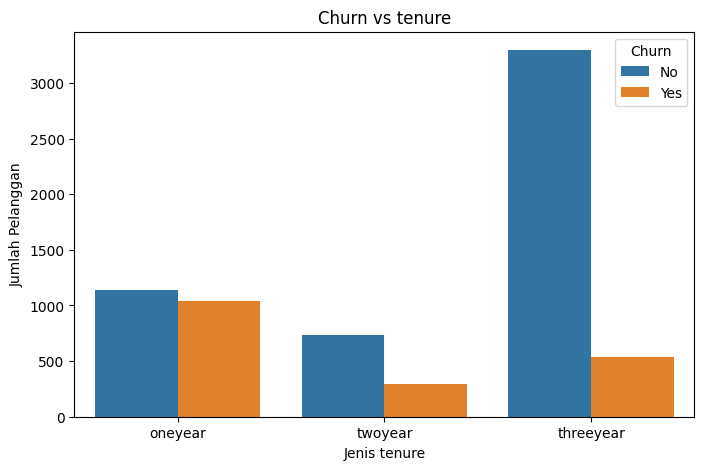

In [7]:
# boxplot untuk fitur tenure 
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='tenure', hue='Churn')
plt.title('Churn vs tenure')
plt.ylabel('Jumlah Pelanggan')
plt.xlabel('Jenis tenure')
plt.legend(title='Churn')
plt.show()

In [8]:
# uji chi square untuk fitur tenure
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['tenure'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f'Chi2: {chi2}, p-value: {p}, dof: {dof}')
# uji chi square untuk fitur Churn
if p < 0.05:
    print("Ada hubungan signifikan antara tenure dan Churn")
else:
    print("Tidak ada hubungan signifikan antara tenure dan Churn")

Chi2: 807.5820584283829, p-value: 4.32298939601873e-176, dof: 2
Ada hubungan signifikan antara tenure dan Churn


In [9]:
# drop fitur totalcharges karena korelasinya tinggi dengan monthlycharges
df = df.drop(columns=['TotalCharges'])

In [10]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Yes,No,oneyear,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,0,No,No,threeyear,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,0,No,No,oneyear,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,0,No,No,threeyear,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,0,No,No,oneyear,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [11]:
# binning tiga fitur lemah hasil chi square, yaitu dependent,seniorcitizen dan partner menjadi is_married, dengan ketentuan is_married = 1 jika seniorcitizen = 1 atau partner = yes atau dependents = yes
df['is_married'] = np.where(
    (df['SeniorCitizen'] == 1) | 
    (df['Partner'] == 'Yes') | 
    (df['Dependents'] == 'Yes'),
    1, 0
)

In [12]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,is_married
0,0,Yes,No,oneyear,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,1
1,0,No,No,threeyear,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No,0
2,0,No,No,oneyear,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,0
3,0,No,No,threeyear,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No,0
4,0,No,No,oneyear,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,0


In [13]:
#print jumlah married 1 dan 0
print(df['is_married'].value_counts())

is_married
1    4313
0    2719
Name: count, dtype: int64


In [14]:
#drop kolom seniorcitizen, partner, dependents
df = df.drop(columns=['SeniorCitizen', 'Partner', 'Dependents'])
df.head()

,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,is_married
0,oneyear,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,1
1,threeyear,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No,0
2,oneyear,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,0
3,threeyear,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No,0
4,oneyear,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,0


In [15]:
# Drop multipleLines karena hasilnya jelek
df = df.drop(columns=['MultipleLines'])
df.head()

,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,is_married
0,oneyear,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,1
1,threeyear,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No,0
2,oneyear,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,0
3,threeyear,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No,0
4,oneyear,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,0


In [16]:
# simpan dataframe yang sudah dibersihkan ke file csv
# df.to_csv('Telecom_Customers_Churn_Cleaned_Final.csv', index=False)

In [17]:
## Split dataset encode label 
from sklearn.model_selection import train_test_split

# Copy dataframe agar aman
df_model = df.copy()

# Pisahkan fitur & target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn'].map({'No': 0, 'Yes': 1})  # encode target jadi 0/1

# Split train-test dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((5625, 13), (1407, 13), (5625,), (1407,))

In [19]:
# Simpan data train-test ke file CSV

# X_train.to_csv('X_train.csv', index=False)
# X_test.to_csv('X_test.csv', index=False)
# y_train.to_csv('y_train.csv', index=False)
# y_test.to_csv('y_test.csv', index=False)


In [ ]:

# OHE untuk fitur kategorikal data train dan Test
